<a href="https://colab.research.google.com/github/jacunda/POS-DATASCIENCE-IA/blob/main/ReinforcementLearning/exercicios_agente_labirinto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercícios: Agente em Labirinto e FrozenLake

Neste notebook você vai praticar os conceitos vistos em aula:

- Representar um ambiente como uma grade 2D
- Implementar movimentação de um agente
- Visualizar o ambiente com matplotlib
- Analisar o comportamento de um agente

Cada exercício possui um espaço com `# SEU CÓDIGO AQUI` onde você deve completar a implementação.

---
**Legenda dos mapas:**
- `0` → Caminho livre (branco)
- `1` → Obstáculo / Buraco (azul)
- `2` → Objetivo (verde)
- 🔴 → Agente (círculo vermelho)

## Importações

Execute esta célula antes de qualquer exercício.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import clear_output
import time

---
##  Exercício 1 — Criando o Mapa

Crie um labirinto 5x5 usando `numpy`. O mapa deve ter:
- `0` nas células livres
- `1` nos obstáculos

O mapa abaixo já está parcialmente preenchido. **Complete as linhas faltantes** para montar um labirinto com pelo menos 5 obstáculos.

In [3]:
n_rows, n_cols = 5, 5

maze = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 1, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 1, 1, 0, 0],
    [0, 0, 0, 0, 2]

])

print("Meu labirinto:")
print(maze)
print(f"\nTotal de obstáculos: {np.sum(maze == 1)}")
print(f"Total de células livres: {np.sum(maze == 0)}")

Meu labirinto:
[[0 0 0 0 0]
 [0 1 1 0 0]
 [0 0 0 1 0]
 [0 1 1 0 0]
 [0 0 0 0 2]]

Total de obstáculos: 5
Total de células livres: 19


<details>
<summary> Dica</summary>

O mapa precisa ter exatamente 5 linhas (você já tem 2). Use 0 para livre e 1 para obstáculo. Exemplo de linha: `[0, 1, 0, 0, 1]`
</details>

---
## Exercício 2 — Visualizando o Labirinto

Complete a função `desenhar_labirinto` para exibir o mapa usando matplotlib.

- Células `0` → cor branca
- Células `1` → cor azul claro (`'lightblue'`)
- O agente → círculo vermelho na posição fornecida

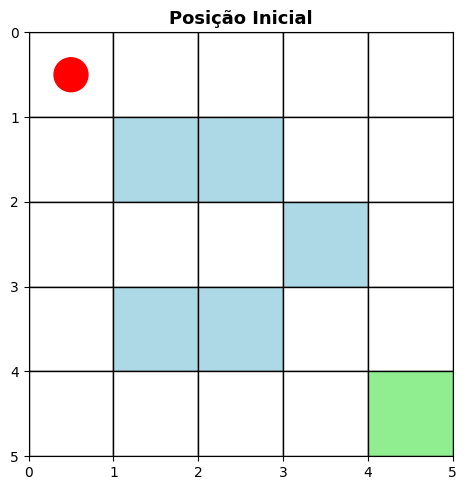

In [4]:
def desenhar_labirinto(agent_position, titulo="Labirinto"):
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    for row in range(n_rows):
        for col in range(n_cols):
          if maze[row, col] == 0:
              color = 'white'
          elif maze[row, col] == 1:
              color = 'lightblue'
          elif maze[row, col] == 2:
              color = 'lightgreen'

          rect = patches.Rectangle((col, row), 1, 1,
                                      linewidth=1, edgecolor='black',
                                      facecolor=color)
          ax.add_patch(rect)

    # SEU CÓDIGO AQUI:
    # Desenhe um círculo vermelho na posição do agente
    # Dica: patches.Circle((x, y), raio, color='red')
    # x = agent_position[1] + 0.5
    # y = agent_position[0] + 0.5

    x = agent_position[1] + 0.5
    y = agent_position[0] + 0.5
    circle = patches.Circle((x, y), 0.2, color='red', zorder=5)
    ax.add_patch(circle)

    ax.set_xlim(0, n_cols)
    ax.set_ylim(n_rows, 0)
    ax.set_aspect('equal')
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Teste sua função:
desenhar_labirinto([0, 0], titulo="Posição Inicial")

<details>
<summary>Dica</summary>

```python
if maze[row, col] == 0:
    color = 'white'
else:
    color = 'lightblue'
```

Para o círculo:
```python
circulo = patches.Circle((agent_position[1] + 0.5, agent_position[0] + 0.5), 0.3, color='red')
ax.add_patch(circulo)
```
</details>

---
## Exercício 3 — Ação Aleatória

Implemente a função `acao_aleatoria()` que retorna aleatoriamente uma das quatro direções possíveis: `'up'`, `'down'`, `'left'`, `'right'`.

In [8]:
def acao_aleatoria():
    # SEU CÓDIGO AQUI
    return np.random.choice(['up', 'down', 'left', 'right'])

# Teste: gere 10 ações aleatórias
acoes_geradas = [acao_aleatoria() for _ in range(10)]
print("10 ações aleatórias geradas:")
print(acoes_geradas)

10 ações aleatórias geradas:
[np.str_('right'), np.str_('up'), np.str_('down'), np.str_('left'), np.str_('down'), np.str_('down'), np.str_('up'), np.str_('down'), np.str_('right'), np.str_('right')]


<details>
<summary>Dica</summary>

Use `np.random.choice(['up', 'down', 'left', 'right'])`
</details>

---
## Exercício 4 — Atualizar Posição do Agente

Implemente a função `atualizar_posicao(posicao_atual, acao)` que:

1. Calcula a nova posição com base na ação
2. **Não** permite sair dos limites do mapa
3. **Não** permite mover para células com obstáculo (`maze == 1`)
4. Retorna a nova posição (ou a mesma, se o movimento for inválido)

| Ação | Comportamento |
|------|---------------|
| `'up'` | diminui a linha (`row - 1`) |
| `'down'` | aumenta a linha (`row + 1`) |
| `'left'` | diminui a coluna (`col - 1`) |
| `'right'` | aumenta a coluna (`col + 1`) |

In [14]:
def atualizar_posicao(posicao_atual, acao):
    row, col = posicao_atual

    if acao == 'up' and row > 0 and maze[row - 1, col] == 0:
        return [row - 1, col]
    elif acao == 'down' and row < n_rows - 1 and maze[row + 1, col] == 0:
        return [row + 1, col]
    elif acao == 'left' and col > 0 and maze[row, col - 1] == 0:
        return [row, col - 1]
    elif acao == 'right' and col < n_cols - 1 and maze[row, col + 1] == 0:
        return [row, col + 1]

    return posicao_atual  # retorna sem mudança se inválido ou bater na borda/obstáculo

# Testes básicos:
print(atualizar_posicao([0, 0], 'down'))   # deve ser [1, 0]
print(atualizar_posicao([0, 0], 'up'))     # deve ser [0, 0] (borda)
print(atualizar_posicao([0, 0], 'right'))  # deve ser [0, 1]

[1, 0]
[0, 0]
[0, 1]


<details>
<summary>Dica</summary>

Para o movimento `'up'` (sobe no mapa = row diminui):
```python
if acao == 'up' and row > 0 and maze[row - 1, col] == 0:
    return [row - 1, col]
```
Repita a lógica para as outras direções trocando os índices corretamente.
</details>

---
## Exercício 5 — Loop de Simulação

Agora junte tudo! Implemente o loop principal da simulação:

1. Comece na posição `[0, 0]`
2. A cada passo, escolha uma ação aleatória
3. Atualize a posição
4. Imprima: número do passo, ação, posição anterior e nova posição
5. Repita por `num_passos = 15` passos

In [15]:
num_passos = 15
posicao_agente = [0, 0]

print("Simulação iniciada!")
print(f"Posição inicial: {posicao_agente}")
print("-" * 50)

for passo in range(num_passos):
    acao = acao_aleatoria()
    pos_anterior = posicao_agente.copy()
    posicao_agente = atualizar_posicao(posicao_agente, acao)
    print(f"Passo {passo:2d}: {acao:6s} | {pos_anterior} → {posicao_agente}")
    # SEU CÓDIGO AQUI:
    # 1. Escolha uma ação aleatória
    # 2. Salve a posição anterior
    # 3. Atualize a posição
    # 4. Imprima as informações do passo
    pass

print("-" * 50)
print(f"Posição final: {posicao_agente}")

Simulação iniciada!
Posição inicial: [0, 0]
--------------------------------------------------
Passo  0: up     | [0, 0] → [0, 0]
Passo  1: left   | [0, 0] → [0, 0]
Passo  2: up     | [0, 0] → [0, 0]
Passo  3: left   | [0, 0] → [0, 0]
Passo  4: up     | [0, 0] → [0, 0]
Passo  5: right  | [0, 0] → [0, 1]
Passo  6: up     | [0, 1] → [0, 1]
Passo  7: up     | [0, 1] → [0, 1]
Passo  8: up     | [0, 1] → [0, 1]
Passo  9: up     | [0, 1] → [0, 1]
Passo 10: right  | [0, 1] → [0, 2]
Passo 11: left   | [0, 2] → [0, 1]
Passo 12: up     | [0, 1] → [0, 1]
Passo 13: right  | [0, 1] → [0, 2]
Passo 14: up     | [0, 2] → [0, 2]
--------------------------------------------------
Posição final: [0, 2]


<details>
<summary>Dica</summary>

```python
for passo in range(num_passos):
    acao = acao_aleatoria()
    pos_anterior = posicao_agente.copy()
    posicao_agente = atualizar_posicao(posicao_agente, acao)
    print(f"Passo {passo:2d}: {acao:6s} | {pos_anterior} → {posicao_agente}")
```
</details>

---
## Exercício 6 — FrozenLake: Mapa com Objetivo

Crie o mapa FrozenLake 4x4 com:
- `0` = caminho livre
- `1` = buraco
- `2` = objetivo (apenas 1 célula)

O objetivo **deve estar em `[3, 3]`** (última linha, última coluna).

In [16]:
n_rows_fl, n_cols_fl = 4, 4

# SEU CÓDIGO AQUI:
# Crie o mapa frozen_lake_map com np.array
# Deve ter: 0s (livre), 1s (buraco) e um 2 na posição [3,3]

# Criando o mapa FrozenLake (0 para caminhos livres, 1 para buracos, 2 para o objetivo)
frozen_lake_map = np.array([
    [0, 0, 0, 0],
    [0, 1, 0, 1],
    [0, 0, 0, 0],
    [0, 1, 0, 2]
])

print("Mapa do FrozenLake:")
print(frozen_lake_map)
print("\nLegenda: 0=Livre, 1=Buraco, 2=Objetivo")

print("Mapa FrozenLake:")
print(frozen_lake_map)
print(f"\nBuracos: {np.sum(frozen_lake_map == 1)}")
print(f"Objetivo está em [3,3]? {frozen_lake_map[3, 3] == 2}")

Mapa do FrozenLake:
[[0 0 0 0]
 [0 1 0 1]
 [0 0 0 0]
 [0 1 0 2]]

Legenda: 0=Livre, 1=Buraco, 2=Objetivo
Mapa FrozenLake:
[[0 0 0 0]
 [0 1 0 1]
 [0 0 0 0]
 [0 1 0 2]]

Buracos: 3
Objetivo está em [3,3]? True


<details>
<summary>Dica</summary>

```python
frozen_lake_map = np.array([
    [0, 0, 0, 0],
    [0, 1, 0, 1],
    [0, 0, 0, 1],
    [0, 1, 0, 2]
])
```
</details>

---
## Exercício 7 — Visualizando o FrozenLake

Complete a função `desenhar_frozen_lake` para exibir o mapa FrozenLake.

Desta vez temos 3 tipos de célula:
- `0` → branco
- `1` → azul claro (`'lightblue'`)
- `2` → verde claro (`'lightgreen'`)

E o agente continua sendo um círculo vermelho.

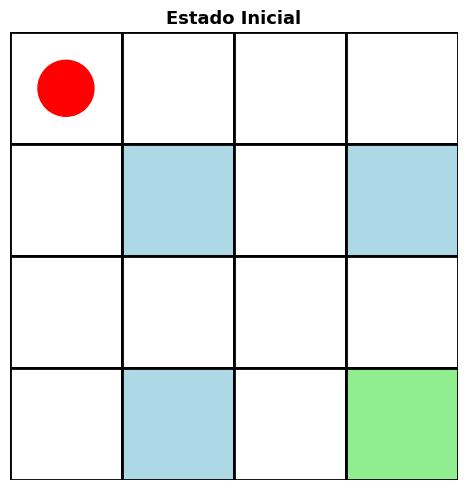

In [18]:
def desenhar_frozen_lake(agent_pos, titulo="FrozenLake"):
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    for row in range(n_rows_fl):
        for col in range(n_cols_fl):
            # SEU CÓDIGO AQUI:
            # Defina a cor baseada em frozen_lake_map[row, col]
            # 0 → 'white', 1 → 'lightblue', 2 → 'lightgreen'
            cores = {0: 'white', 1: 'lightblue', 2: 'lightgreen'}
            color = cores[frozen_lake_map[row, col]]


            rect = patches.Rectangle((col, n_rows_fl - 1 - row), 1, 1,
                                      linewidth=2, edgecolor='black',
                                      facecolor=color)
            ax.add_patch(rect)

    # SEU CÓDIGO AQUI: adicione o agente (círculo vermelho)
    # Atenção: o eixo y está invertido! Use n_rows_fl - 1 - agent_pos[0]

    ax.add_patch(patches.Circle(
        (agent_pos[1] + 0.5, n_rows_fl - 1 - agent_pos[0] + 0.5),
        0.25, color='red'
    ))

    ax.set_xlim(0, n_cols_fl)
    ax.set_ylim(0, n_rows_fl)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Teste:
desenhar_frozen_lake([0, 0], titulo="Estado Inicial")

<details>
<summary>💡 Dica</summary>

```python
cores = {0: 'white', 1: 'lightblue', 2: 'lightgreen'}
color = cores[frozen_lake_map[row, col]]
```

Para o agente com eixo invertido:
```python
ax.add_patch(patches.Circle(
    (agent_pos[1] + 0.5, n_rows_fl - 1 - agent_pos[0] + 0.5),
    0.25, color='red'
))
```
</details>

---
## Exercício 8 — Verificar Estado do Jogo

Implemente a função `verificar_estado(posicao)` que:

- Retorna `'buraco'` se o agente caiu em um buraco (`1`)
- Retorna `'objetivo'` se o agente chegou ao objetivo (`2`)
- Retorna `'jogando'` se o agente está em célula livre (`0`)

In [19]:
def verificar_estado(posicao):
  celula = frozen_lake_map[posicao[0], posicao[1]]
  if celula == 1:
    return 'buraco'
  elif celula == 2:
    return 'objetivo'
  else:
    return 'jogando'

# Testes:
print(verificar_estado([0, 0]))  # 'jogando'
print(verificar_estado([3, 3]))  # 'objetivo'
print(verificar_estado([1, 1]))  # 'buraco' (se houver buraco em [1,1])

jogando
objetivo
buraco


<details>
<summary>Dica</summary>

```python
celula = frozen_lake_map[posicao[0], posicao[1]]
if celula == 1:
    return 'buraco'
elif celula == 2:
    return 'objetivo'
else:
    return 'jogando'
```
</details>

---
## Exercício 9 — Simulação Completa do FrozenLake

Combine tudo o que foi feito para simular o agente no FrozenLake!

O loop deve:
1. Escolher uma ação aleatória
2. Atualizar a posição (use a função do Exercício 4, adaptada para o FrozenLake)
3. Verificar o estado
4. **Parar** se o agente cair em um buraco **ou** chegar ao objetivo
5. Visualizar o mapa a cada passo

> Crie uma variável `max_passos = 30` para evitar loop infinito.

In [20]:
# Função auxiliar de movimento adaptada para o FrozenLake
def mover_no_frozen_lake(posicao, acao):
    row, col = posicao

    if acao == 'up' and row > 0:
        return [row - 1, col]
    elif acao == 'down' and row < n_rows_fl - 1:
        return [row + 1, col]
    elif acao == 'left' and col > 0:
        return [row, col - 1]
    elif acao == 'right' and col < n_cols_fl - 1:
        return [row, col + 1]
    return posicao  # sem movimento válido

Simulação FrozenLake
Passo  0: right  → [0, 1] | jogando
Passo  1: left   → [0, 0] | jogando
Passo  2: down   → [1, 0] | jogando
Passo  3: right  → [1, 1] | buraco
💥 Caiu em um buraco!


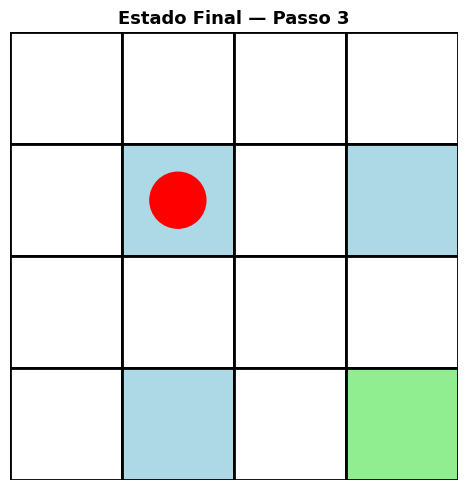

In [21]:
max_passos = 30
pos = [0, 0]

print("=" * 50)
print("Simulação FrozenLake")
print("=" * 50)

for passo in range(max_passos):
    acao = acao_aleatoria()
    pos = mover_no_frozen_lake(pos, acao)
    estado = verificar_estado(pos)
    print(f"Passo {passo:2d}: {acao:6s} → {pos} | {estado}")
    if estado != 'jogando':
        if estado == 'objetivo':
            print("🎉 Objetivo alcançado!")
        else:
            print("💥 Caiu em um buraco!")
        break

# Visualize o estado final
desenhar_frozen_lake(pos, titulo=f"Estado Final — Passo {passo}")

<details>
<summary>Dica</summary>

```python
for passo in range(max_passos):
    acao = acao_aleatoria()
    pos = mover_no_frozen_lake(pos, acao)
    estado = verificar_estado(pos)
    print(f"Passo {passo:2d}: {acao:6s} → {pos} | {estado}")
    if estado != 'jogando':
        if estado == 'objetivo':
            print("🎉 Objetivo alcançado!")
        else:
            print("💥 Caiu em um buraco!")
        break
```
</details>

---
## Exercício 10 — Análise do Agente

Execute a simulação do FrozenLake **100 vezes** e responda:

1. Quantas vezes o agente chegou ao objetivo?
2. Quantas vezes o agente caiu em um buraco?
3. Quantas vezes o agente não terminou (atingiu `max_passos`)?

Exiba os resultados em formato de porcentagem.

In [23]:
n_episodios = 100
max_passos = 50

contagem = {'objetivo': 0, 'buraco': 0, 'timeout': 0}

for episodio in range(n_episodios):
    pos = [0, 0]
    resultado = 'timeout'

    for passo in range(max_passos):
        # SEU CÓDIGO AQUI:
        # 1. Escolha uma ação, mova o agente, verifique o estado
        # 2. Se o estado não for 'jogando', registre o resultado e quebre

        acao = acao_aleatoria()
        pos = mover_no_frozen_lake(pos, acao)
        estado = verificar_estado(pos)
        if estado != 'jogando':
            resultado = estado
            break


    contagem[resultado] += 1

print("=" * 40)
print(f"Resultados após {n_episodios} episódios:")
print("=" * 40)
for chave, valor in contagem.items():
    print(f"{chave:10s}: {valor:3d} ({valor/n_episodios*100:.1f}%)")

Resultados após 100 episódios:
objetivo  :   3 (3.0%)
buraco    :  97 (97.0%)
timeout   :   0 (0.0%)


<details>
<summary>Dica</summary>

Dentro do loop de passos:
```python
acao = acao_aleatoria()
pos = mover_no_frozen_lake(pos, acao)
estado = verificar_estado(pos)
if estado != 'jogando':
    resultado = estado
    break
```
</details>

---
## Reflexão Final

Responda as perguntas abaixo em texto (clique duas vezes para editar):

**1. Com um agente aleatório, qual é a taxa de sucesso esperada no FrozenLake? Por quê ela é baixa?**

> *Sua resposta aqui...*

**2. O que seria necessário para melhorar o desempenho do agente?**

> *Sua resposta aqui...*

**3. No labirinto do Exercício 5, o agente pode ficar preso em alguma situação? Por quê?**

> *Sua resposta aqui...*

---
**Parabéns por concluir os exercícios!**

Você implementou um ambiente de grade, movimentação de agente, visualização com matplotlib e análise estatística de comportamento — todos os blocos fundamentais para explorar técnicas de aprendizado por reforço como **Q-Learning** nas próximas aulas!